In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('/content/heart_disease_data.csv')

Target counts:
target
1    165
0    138
Name: count, dtype: int64

Target percentage:
target
1    54.455446
0    45.544554
Name: proportion, dtype: float64


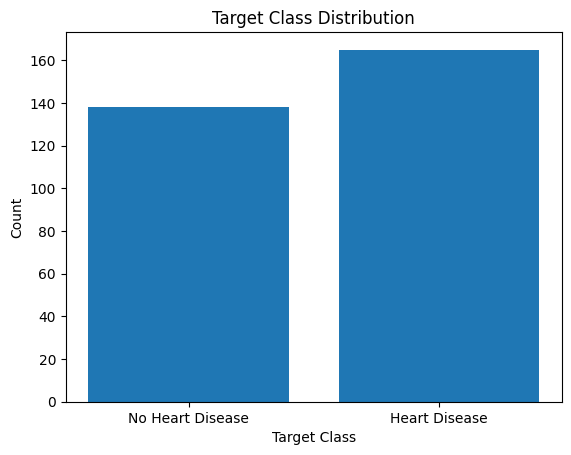

In [3]:
#  Check target imbalance
target_counts = heart_data['target'].value_counts()
target_percent = heart_data['target'].value_counts(normalize=True) * 100

print("Target counts:")
print(target_counts)

print("\nTarget percentage:")
print(target_percent)

# Visualizing target imbalance
target_counts = heart_data['target'].value_counts()

plt.figure()
plt.bar(target_counts.index, target_counts.values)
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.title('Target Class Distribution')
plt.xticks([0, 1], ['No Heart Disease', 'Heart Disease'])
plt.show()


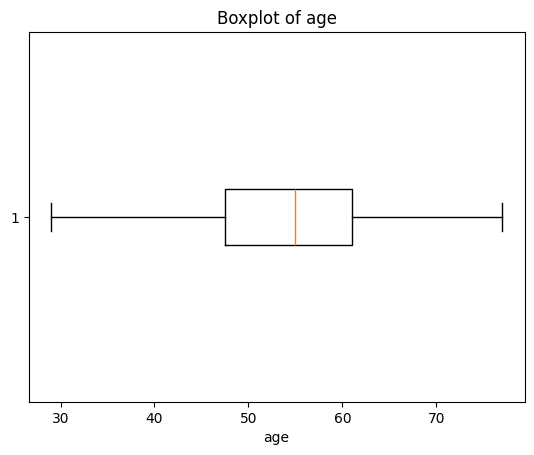

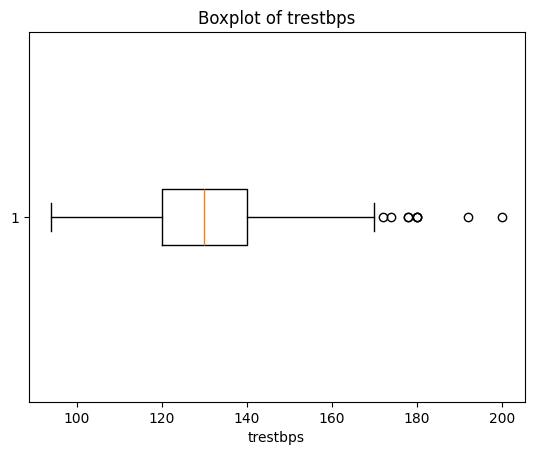

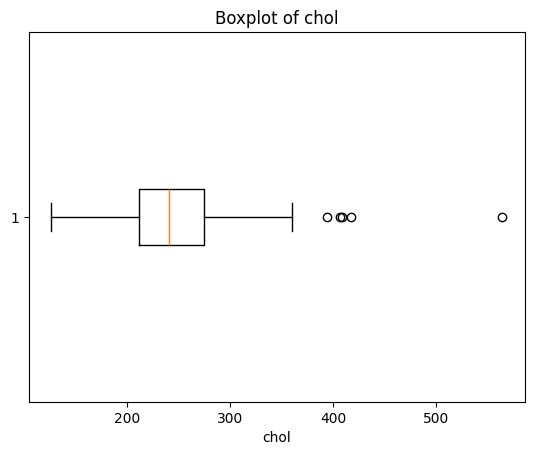

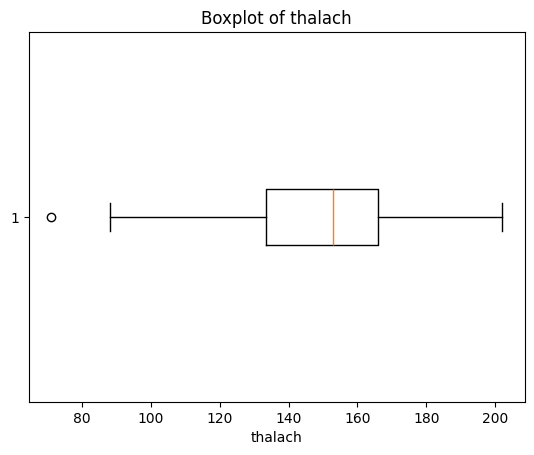

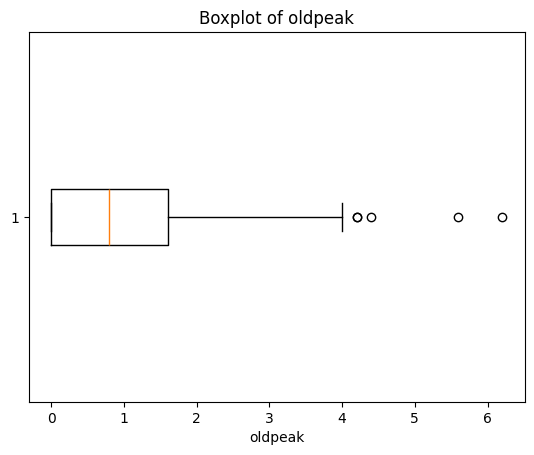

In [4]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Outlier visualization for non-binary columns only
for col in continuous_cols:
    plt.figure()
    plt.boxplot(heart_data[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()


In [5]:
# Outlier handling (IQR capping) for non-binary columns

heart_data_clean = heart_data.copy()

for col in continuous_cols:
    Q1 = heart_data_clean[col].quantile(0.25)
    Q3 = heart_data_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    heart_data_clean[col] = heart_data_clean[col].clip(lower_bound, upper_bound)

print("Outliers capped using IQR method.")


Outliers capped using IQR method.


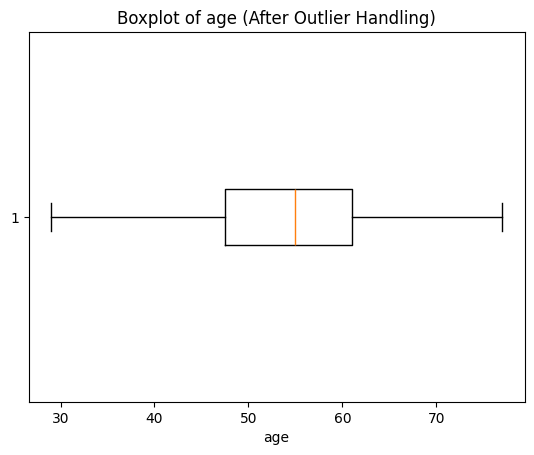

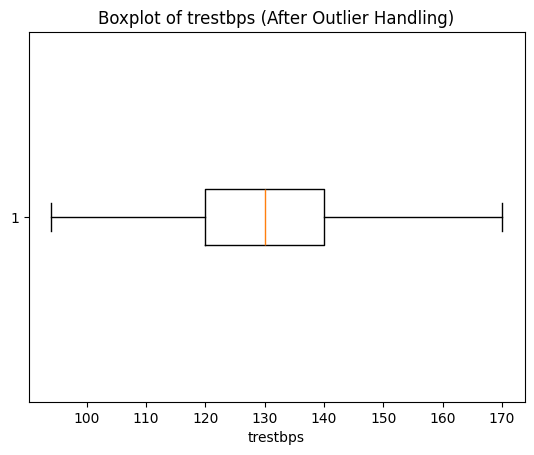

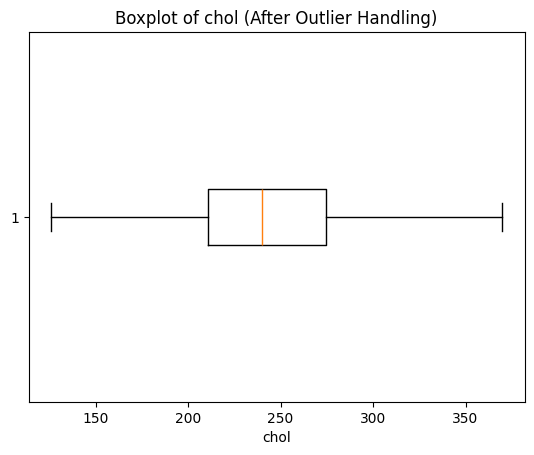

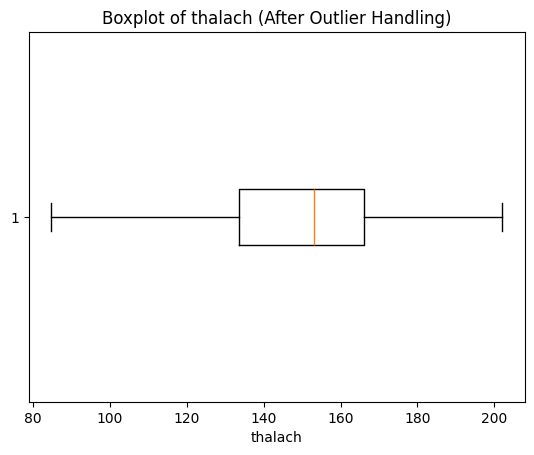

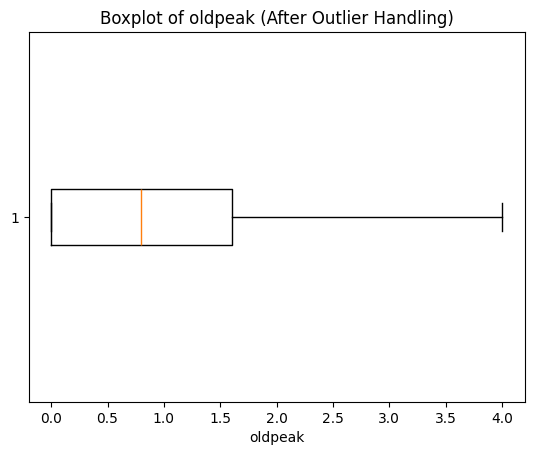

In [6]:
for col in continuous_cols:
    plt.figure()
    plt.boxplot(heart_data_clean[col], vert=False)
    plt.title(f'Boxplot of {col} (After Outlier Handling)')
    plt.xlabel(col)
    plt.show()

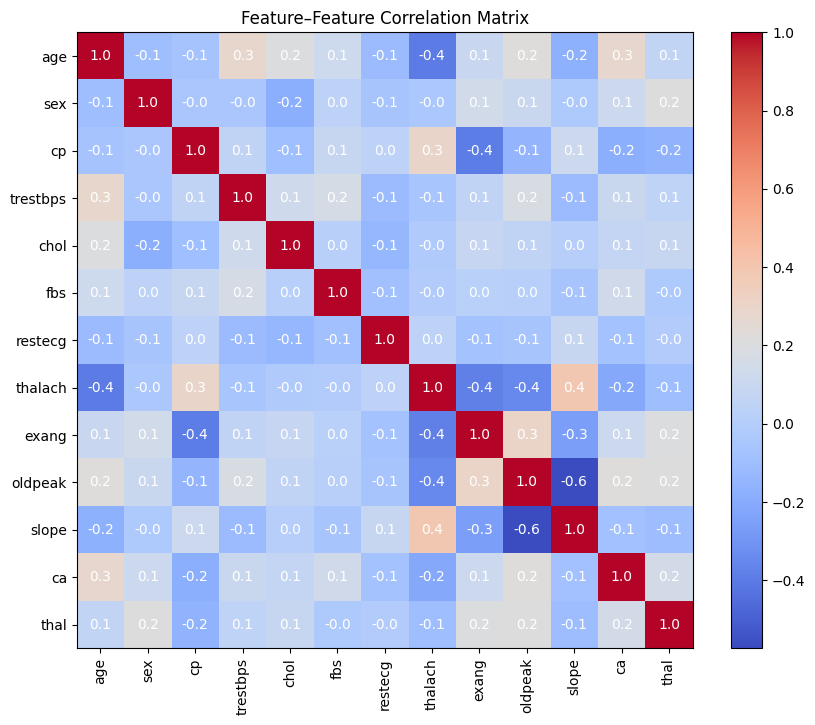

In [7]:
# 1) Feature–Feature Correlation Matrix (exclude target)
# ======================================================
corr_matrix = heart_data_clean.drop(columns='target').corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()

# Axis ticks
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Add values inside each cell
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.1f}", ha="center", va="center", color="white")

plt.title('Feature–Feature Correlation Matrix')
plt.show()

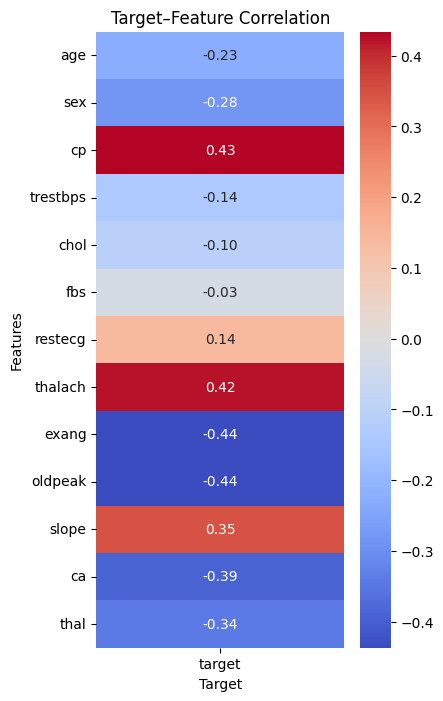

In [8]:
# 2) Target–Feature Correlation Heatmap
# ======================================================
plt.figure(figsize=(4, 8))
corr_tf = heart_data_clean.corr()[['target']].drop('target')
sns.heatmap(corr_tf, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Target–Feature Correlation")
plt.ylabel("Features")
plt.xlabel("Target")
plt.show()



In [9]:
# 3) Drop one feature from highly correlated pairs (>0.8)
#    based on stronger |feature-target correlation|
# ======================================================
high_corr_threshold = 0.80

# absolute feature-feature corr
ff_abs = corr_matrix.abs()

# upper triangle to avoid duplicates
upper = ff_abs.where(np.triu(np.ones(ff_abs.shape), k=1).astype(bool))

# feature-target abs correlation
ft_abs = heart_data_clean.corr()['target'].abs()

to_drop_highcorr = set()

for col in upper.columns:
    for row in upper.index:
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > high_corr_threshold:
            # compare which one has lower target correlation
            if ft_abs[row] < ft_abs[col]:
                to_drop_highcorr.add(row)
            else:
                to_drop_highcorr.add(col)

# drop selected redundant features
heart_data_clean = heart_data_clean.drop(columns=list(to_drop_highcorr), errors='ignore')
print("Dropped (high feature–feature correlation):", list(to_drop_highcorr))


Dropped (high feature–feature correlation): []


In [10]:
# 4) Drop weak target-correlated features (< threshold)
# ======================================================
target_threshold = 0.10

corr_target_abs = heart_data_clean.corr()['target'].abs()
weak_features = corr_target_abs[corr_target_abs < target_threshold].index
weak_features = weak_features.drop('target', errors='ignore')

heart_data_clean = heart_data_clean.drop(columns=weak_features, errors='ignore')

print("Dropped (weak target correlation):", list(weak_features))
print("Final columns:", heart_data_clean.columns.tolist())

Dropped (weak target correlation): ['fbs']
Final columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [12]:
# 4) DROP REDUNDANT FEATURES (FEATURE–FEATURE)
feature_corr = heart_data_clean.drop(columns=['target']).corr().abs()

upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

high_corr_threshold = 0.80
redundant_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > high_corr_threshold)
]

heart_data_clean = heart_data_clean.drop(columns=redundant_features)

print("Dropped (high feature–feature correlation):", redundant_features)

# 5) FINAL FEATURE LIST
print("Final selected features:")
print(heart_data_clean.columns.tolist())

Dropped (high feature–feature correlation): []
Final selected features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [13]:
# Separate classes
data_0 = heart_data_clean[heart_data_clean['target'] == 0]
data_1 = heart_data_clean[heart_data_clean['target'] == 1]


min_count = min(len(data_0), len(data_1))

# Randomly sample equal rows
data_0_bal = data_0.sample(min_count, random_state=42)
data_1_bal = data_1.sample(min_count, random_state=42)

# Combine and shuffle
heart_data_balanced = (
    pd.concat([data_0_bal, data_1_bal])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Check balance
print(heart_data_balanced['target'].value_counts())
print(heart_data_balanced['target'].value_counts(normalize=True) * 100)


target
0    138
1    138
Name: count, dtype: int64
target
0    50.0
1    50.0
Name: proportion, dtype: float64


In [14]:
# Separate features and target
X = heart_data_balanced.drop(columns='target', axis=1)
Y = heart_data_balanced['target']

In [15]:
# ----shuffle and train-test split (80-20) ----
np.random.seed(2)
indices = np.arange(len(X))
np.random.shuffle(indices)

train_size = int(0.8 * len(X))
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]
Y_train = Y.iloc[train_indices]
Y_test = Y.iloc[test_indices]

In [16]:
# ----Standardization ----
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

for col in X_train.columns:
    mean_val = sum(X_train[col]) / len(X_train[col])
    std_val = (sum((X_train[col] - mean_val) ** 2) / len(X_train[col])) ** 0.5

    X_train_scaled[col] = [(val - mean_val) / std_val for val in X_train[col]]
    X_test_scaled[col] = [(val - mean_val) / std_val for val in X_test[col]]

In [ ]:
X_train_scaled.head()


,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal
154,1.485197,0.675983,-0.917245,0.783908,-1.122616,0.907231,-0.334972,-0.719195,2.005836,-0.591714,1.343687,1.091285
7,-1.155153,0.675983,0.071941,-0.656257,-0.566840,0.907231,0.934292,-0.719195,-0.933751,1.015410,-0.695011,-0.587615
99,1.375182,0.675983,1.061127,1.263963,-0.731514,-0.993634,0.058937,-0.719195,-0.242084,-0.591714,-0.695011,1.091285
13,0.165022,0.675983,0.071941,-0.656257,-0.237491,0.907231,1.284434,-0.719195,-0.242084,1.015410,-0.695011,-0.587615
112,-1.265168,0.675983,-0.917245,-0.956291,1.141656,0.907231,1.415737,-0.719195,0.103750,-0.591714,-0.695011,-0.587615


In [17]:
# ---- Check mean and std of each scaled feature ----
scaling_stats = pd.DataFrame({
    'mean': X_train_scaled.mean(),
    'std': X_train_scaled.std(),
    'min': X_train_scaled.min(),
    'max': X_train_scaled.max()
})

scaling_stats


,mean,std,min,max
age,-4.037175e-18,1.002281,-2.805372,2.475328
sex,-8.124814e-17,1.002281,-1.479326,0.675983
cp,4.037175e-18,1.002281,-0.917245,2.050313
trestbps,-8.074349e-18,1.002281,-1.856395,2.344087
chol,1.211152e-16,1.002281,-2.501764,2.515658
restecg,1.614870e-17,1.002281,-0.993634,2.808096
thalach,-1.130409e-16,1.002281,-2.796908,2.334860
exang,1.049665e-16,1.002281,-0.719195,1.390444
oldpeak,-3.229740e-17,1.002281,-0.933751,2.524586
slope,8.074349e-17,1.002281,-2.198838,1.015410


In [18]:
import json, joblib, numpy as np

# ✅ 1) Feature names (must be from the DataFrame, before .to_numpy())
final_feature_columns = list(X_train_scaled.columns)

# ✅ 2) Save the SAME mean/std you used in your standardization loop
# (recompute using your exact formula: population std)
scaler_params = {}
for col in X_train.columns:   # X_train is still a DataFrame here (cell 13 output)
    mean_val = float(sum(X_train[col]) / len(X_train[col]))
    std_val  = float((sum((X_train[col] - mean_val) ** 2) / len(X_train[col])) ** 0.5)
    if std_val == 0:
        std_val = 1.0
    scaler_params[col] = {"mean": mean_val, "std": std_val}

# ✅ 3) Outlier clip bounds (same IQR method you used)
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
clip_bounds = {}
for col in continuous_cols:
    Q1 = heart_data[col].quantile(0.25)
    Q3 = heart_data[col].quantile(0.75)
    IQR = Q3 - Q1
    clip_bounds[col] = {
        "lower": float(Q1 - 1.5 * IQR),
        "upper": float(Q3 + 1.5 * IQR)
    }

print("✅ Saved preprocessing configs in memory (feature columns / scaler / clip bounds).")
print("Features:", final_feature_columns)
print("Num features:", len(final_feature_columns))


✅ Saved preprocessing configs in memory (feature columns / scaler / clip bounds).
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Num features: 12


In [19]:


# 1) Prepare data
X_train = X_train_scaled.to_numpy(dtype=float)
y_train = np.array(Y_train, dtype=float)

X_test  = X_test_scaled.to_numpy(dtype=float)
y_test  = np.array(Y_test, dtype=float)

rows, cols = X_train.shape

# 2) Initialize parameters
weights = np.zeros(cols, dtype=float)
bias = 0.0

# 3) Hyperparameters
learning_rate = 0.005
epochs = 2000
threshold = 0.4

# 4) Sigmoid (stable)
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

# 5) Training (SGD + shuffle each epoch)
for epoch in range(epochs):
    idx = np.random.permutation(rows)  # shuffle indices every epoch
    for i in idx:
        z = np.dot(X_train[i], weights) + bias
        pred = sigmoid(z)
        error = pred - y_train[i]

        weights -= learning_rate * error * X_train[i]
        bias    -= learning_rate * error

    if epoch % 100 == 0:
        z_all = X_train @ weights + bias
        p_all = sigmoid(z_all)
        eps = 1e-9
        loss = -np.mean(y_train * np.log(p_all + eps) + (1 - y_train) * np.log(1 - p_all + eps))
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# 6) Testing / Prediction
z_test = X_test @ weights + bias
prob_test = sigmoid(z_test)

# Convert probability to class label (0/1)
y_pred = (prob_test >= threshold).astype(int)

# Accuracy
accuracy = np.mean(y_pred == y_test.astype(int))
print("\nFinal Test Accuracy:", accuracy)

# 7) Confusion Matrix (MANUAL)
TP = TN = FP = FN = 0

for i in range(len(y_test)):
    if y_test[i] == 1 and y_pred[i] == 1:
        TP += 1
    elif y_test[i] == 0 and y_pred[i] == 0:
        TN += 1
    elif y_test[i] == 0 and y_pred[i] == 1:
        FP += 1
    elif y_test[i] == 1 and y_pred[i] == 0:
        FN += 1

print("\nCONFUSION MATRIX")
print("--------------------------")
print("              Predicted")
print("            |   0   |   1")
print("--------------------------")
print(f"Actual  0   |  {TN}   |  {FP}")
print(f"Actual  1   |  {FN}   |  {TP}")
print("--------------------------")

# 8) Metrics (important for medical)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall    = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score  = (2 * precision * recall / (precision + recall)) if (precision + recall) != 0 else 0

print("\nMETRICS")
print("----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1_score)


Epoch 0, Loss: 0.4826
Epoch 100, Loss: 0.3147
Epoch 200, Loss: 0.3147
Epoch 300, Loss: 0.3147
Epoch 400, Loss: 0.3147
Epoch 500, Loss: 0.3147
Epoch 600, Loss: 0.3147
Epoch 700, Loss: 0.3147
Epoch 800, Loss: 0.3147
Epoch 900, Loss: 0.3147
Epoch 1000, Loss: 0.3147
Epoch 1100, Loss: 0.3147
Epoch 1200, Loss: 0.3147
Epoch 1300, Loss: 0.3147
Epoch 1400, Loss: 0.3147
Epoch 1500, Loss: 0.3147
Epoch 1600, Loss: 0.3147
Epoch 1700, Loss: 0.3147
Epoch 1800, Loss: 0.3147
Epoch 1900, Loss: 0.3147

Final Test Accuracy: 0.8035714285714286

CONFUSION MATRIX
--------------------------
              Predicted
            |   0   |   1
--------------------------
Actual  0   |  24   |  8
Actual  1   |  3   |  21
--------------------------

METRICS
----------------
Accuracy : 0.8035714285714286
Precision: 0.7241379310344828
Recall   : 0.875
F1 Score : 0.7924528301886793


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ------------------------------------
# Prepare data (already UNSCALED numpy arrays)
# ------------------------------------
X_train_rf = X_train
X_test_rf  = X_test

y_train_rf = Y_train if isinstance(Y_train, (list, tuple)) else Y_train
y_test_rf  = Y_test if isinstance(Y_test, (list, tuple)) else Y_test

# ------------------------------------
# Train Random Forest model
# ------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_rf, y_train_rf)

# ------------------------------------
# Prediction
# ------------------------------------
y_pred_rf = rf.predict(X_test_rf)

# ------------------------------------
# Accuracy & Confusion Matrix
# ------------------------------------
rf_accuracy = accuracy_score(y_test_rf, y_pred_rf)

print("\nRANDOM FOREST ACCURACY")
print("----------------------")
print("Accuracy:", rf_accuracy)

print("\nCONFUSION MATRIX (Random Forest)")
print(confusion_matrix(y_test_rf, y_pred_rf))



RANDOM FOREST ACCURACY
----------------------
Accuracy: 0.75

CONFUSION MATRIX (Random Forest)
[[24  8]
 [ 6 18]]


In [21]:
import numpy as np, json, joblib

# Save custom Logistic Regression params
np.save("lr_weights.npy", weights)
np.save("lr_bias.npy", np.array([bias], dtype=float))

# Save Random Forest model
joblib.dump(rf, "rf_model.joblib")

# Save preprocessing config
with open("preprocess.json", "w") as f:
    json.dump({
        "final_feature_columns": final_feature_columns,
        "continuous_cols": continuous_cols,
        "clip_bounds": clip_bounds,
        "scaler_params": scaler_params
    }, f, indent=2)

print("✅ Saved: lr_weights.npy, lr_bias.npy, rf_model.joblib, preprocess.json")

# Quick safety check
print("✅ Weight shape:", weights.shape)
print("✅ Feature count:", len(final_feature_columns))


✅ Saved: lr_weights.npy, lr_bias.npy, rf_model.joblib, preprocess.json
✅ Weight shape: (12,)
✅ Feature count: 12


In [ ]:
!pip -q install flask pyngrok joblib pandas numpy scikit-learn


In [22]:
import os
os.makedirs("templates", exist_ok=True)


In [23]:
%%writefile app.py
from flask import Flask, render_template, request
import json, joblib
import numpy as np
import pandas as pd

app = Flask(__name__)

with open("preprocess.json", "r") as f:
    cfg = json.load(f)

FINAL_COLS = cfg["final_feature_columns"]
CONT_COLS  = cfg["continuous_cols"]
CLIP       = cfg["clip_bounds"]
SCALER     = cfg["scaler_params"]

rf_model = joblib.load("rf_model.joblib")
lr_w = np.load("lr_weights.npy")
lr_b = float(np.load("lr_bias.npy")[0])

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def preprocess_one(form_dict):
    # Build row in exact feature order
    row = {}
    for col in FINAL_COLS:
        if col not in form_dict:
            raise ValueError(f"Missing field: {col}")
        row[col] = float(form_dict[col])

    df = pd.DataFrame([row])

    # IQR clip
    for col in CONT_COLS:
        if col in df.columns:
            lo = CLIP[col]["lower"]
            hi = CLIP[col]["upper"]
            df[col] = df[col].clip(lo, hi)

    # Standardize using saved mean/std
    for col in FINAL_COLS:
        mean = SCALER[col]["mean"]
        std  = SCALER[col]["std"]
        if std == 0:
            std = 1.0
        df[col] = (df[col] - mean) / std

    return df[FINAL_COLS].to_numpy(dtype=float)

def predict_lr(X):
    z = float(X @ lr_w + lr_b)
    p = float(sigmoid(z))
    pred = 1 if p >= 0.5 else 0
    return pred, p

def predict_rf(X):
    pred = int(rf_model.predict(X)[0])
    p = float(rf_model.predict_proba(X)[0][1]) if hasattr(rf_model, "predict_proba") else None
    return pred, p

@app.route("/", methods=["GET", "POST"])
def index():
    result = None
    if request.method == "POST":
        try:
            model_choice = request.form.get("model_choice", "lr")
            data = request.form.to_dict()
            data.pop("model_choice", None)

            X = preprocess_one(data)

            if model_choice == "lr":
                pred, p = predict_lr(X)
                model_name = "Logistic Regression (SGD)"
            else:
                pred, p = predict_rf(X)
                model_name = "Random Forest"

            label = "Heart Disease (Positive)" if pred == 1 else "No Heart Disease (Negative)"
            if p is not None:
                result = f"{model_name}: {label} | Probability: {p:.3f}"
            else:
                result = f"{model_name}: {label}"

        except Exception as e:
            result = f"Error: {e}"

    return render_template("index.html", columns=FINAL_COLS, result=result)

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)


Overwriting app.py


In [24]:
%%writefile templates/index.html
<!doctype html>
<html>
<head>
  <meta charset="utf-8"/>
  <title>Heart Disease Prediction</title>
  <style>
    body { font-family: Arial; max-width: 900px; margin: 40px auto; }
    .grid { display: grid; grid-template-columns: 1fr 1fr; gap: 12px; }
    input, select { width: 100%; padding: 10px; }
    button { padding: 12px 18px; margin-top: 16px; cursor: pointer; }
    .result { margin-top: 20px; padding: 12px; background: #f3f3f3; }
  </style>
</head>
<body>
  <h2>Heart Disease Prediction</h2>

  <form method="POST">
    <label>Choose Model</label>
    <select name="model_choice">
      <option value="lr" selected>Logistic Regression (Required)</option>
      <option value="rf">Random Forest</option>
    </select>

    <div class="grid" style="margin-top: 12px;">
      {% for col in columns %}
        <div>
          <label>{{ col }}</label>
          <input name="{{ col }}" type="number" step="any" required>
        </div>
      {% endfor %}
    </div>

    <button type="submit">Predict</button>
  </form>

  {% if result %}
    <div class="result"><b>{{ result }}</b></div>
  {% endif %}
</body>
</html>


Overwriting templates/index.html


In [25]:
from pyngrok import ngrok

ngrok.set_auth_token("38nPT0N5z7QN6W3J9ioq8CrlTos_5NY2XEhAE8NgSAh59Fjdh")
public_url = ngrok.connect(5000)
print("OPEN THIS URL:", public_url)



OPEN THIS URL: NgrokTunnel: "https://nontolerated-undeadened-elena.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
!python app.py


 * Serving Flask app 'app'
 * Debug mode: off
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
Press CTRL+C to quit
127.0.0.1 - - [26/Jan/2026 14:05:14] "GET / HTTP/1.1" 200 -
/content/app.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z = float(X @ lr_w + lr_b)
127.0.0.1 - - [26/Jan/2026 14:06:04] "POST / HTTP/1.1" 200 -
